# Spotify Streams - A Data Analysis Walkthrough 

##### by João Vitor 

In [4]:
# Importing all the libraries we're gonna use in this analysis
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from datetime import date
from pathlib import Path

pd.set_option('display.max_columns', None) # This line allows jupyter to show all the columns when the dataframe is displayed.
#pd.set_option('display.max_rows', None) # Same thing for rows here, but we're not gonna use this. Just kept it for reference.

In [5]:
df = pd.read_csv('spotify-2023.csv',
                sep=',',
                encoding='latin1')
df

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,13,37,1,0,144,A,Major,60,24,39,57,0,8,3
949,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,0,8,0,0,166,F#,Major,42,7,24,83,1,12,6
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,0,7,0,0,92,C#,Major,80,81,67,4,0,8,6
951,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,26,17,0,0,97,C#,Major,82,67,77,8,0,12,5


## Data Exploration

- let's do some data exploration in these cells below, just to see what values we have and which columns we'll use

In [6]:
df.isnull().sum() # Key has null values

track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   track_name            953 non-null    str  
 1   artist(s)_name        953 non-null    str  
 2   artist_count          953 non-null    int64
 3   released_year         953 non-null    int64
 4   released_month        953 non-null    int64
 5   released_day          953 non-null    int64
 6   in_spotify_playlists  953 non-null    int64
 7   in_spotify_charts     953 non-null    int64
 8   streams               953 non-null    str  
 9   in_apple_playlists    953 non-null    int64
 10  in_apple_charts       953 non-null    int64
 11  in_deezer_playlists   953 non-null    str  
 12  in_deezer_charts      953 non-null    int64
 13  in_shazam_charts      903 non-null    str  
 14  bpm                   953 non-null    int64
 15  key                   858 non-null    str  
 16  mode               

## Data Cleaning

- Let's do some cleaning and organizing of our dataset before creating the charts.
- This step is really important. The overall quality of our data, and consequently our visualizations, depends on it, so we need to make sure we're manipulating the data correctly and making the best decisions.

In [8]:
# Let's keep only the columns below and get rid of the rest. They're not important for the kind of analysis we'll create here.

df = df[['track_name', 'artist(s)_name', 'released_year',
       'released_month', 'released_day', 'streams', 'bpm', 'key', 'mode']]
df = df.drop_duplicates() # It's important drop duplicates to clean the dataset

In [9]:
# Creating the decade columns and converting our released year to extract the decade of which year

df['decades'] = df['released_year']
df['decades'] = (np.floor(df['decades'] // 10) * 10).astype(int) # Example of rounding down to the nearest multiple of 10. We use astype(int) because np.floor returns a float.
df['decades'] = df['decades'].astype(str)
df['decades'] = df['decades'].astype(str)
df['decades'] = df['decades'].apply(lambda x : x + "'s") # An example of lambda expression
df

,track_name,artist(s)_name,released_year,released_month,released_day,streams,bpm,key,mode,decades
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2023,7,14,141381703,125,B,Major,2020's
1,LALA,Myke Towers,2023,3,23,133716286,92,C#,Major,2020's
2,vampire,Olivia Rodrigo,2023,6,30,140003974,138,F,Major,2020's
3,Cruel Summer,Taylor Swift,2019,8,23,800840817,170,A,Major,2010's
4,WHERE SHE GOES,Bad Bunny,2023,5,18,303236322,144,A,Minor,2020's
...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,2022,11,3,91473363,144,A,Major,2020's
949,Bigger Than The Whole Sky,Taylor Swift,2022,10,21,121871870,166,F#,Major,2020's
950,A Veces (feat. Feid),"Feid, Paulo Londra",2022,11,3,73513683,92,C#,Major,2020's
951,En La De Ella,"Feid, Sech, Jhayco",2022,10,20,133895612,97,C#,Major,2020's


In [10]:
# Creating the date season release here. We'll use a standard year and only adjust the days and months.
# All calculations will be based on months and days.

summer = pd.Timestamp (2020, 12, 21)
autumn = pd.Timestamp(2020, 3, 21)
winter = pd.Timestamp(2020, 6, 21)
spring = pd.Timestamp(2020, 9, 23)

df['data'] = pd.to_datetime({'year': 2020,
                         'month': df['released_month'],
                         'day': df['released_day']})

# Warning: To perform date calculations, both columns must be in timestamp format. Let's check that.
print(type(df['data'].iloc[0]))
print(type(summer))

df

<class 'pandas.Timestamp'>
<class 'pandas.Timestamp'>


,track_name,artist(s)_name,released_year,released_month,released_day,streams,bpm,key,mode,decades,data
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2023,7,14,141381703,125,B,Major,2020's,2020-07-14
1,LALA,Myke Towers,2023,3,23,133716286,92,C#,Major,2020's,2020-03-23
2,vampire,Olivia Rodrigo,2023,6,30,140003974,138,F,Major,2020's,2020-06-30
3,Cruel Summer,Taylor Swift,2019,8,23,800840817,170,A,Major,2010's,2020-08-23
4,WHERE SHE GOES,Bad Bunny,2023,5,18,303236322,144,A,Minor,2020's,2020-05-18
...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,2022,11,3,91473363,144,A,Major,2020's,2020-11-03
949,Bigger Than The Whole Sky,Taylor Swift,2022,10,21,121871870,166,F#,Major,2020's,2020-10-21
950,A Veces (feat. Feid),"Feid, Paulo Londra",2022,11,3,73513683,92,C#,Major,2020's,2020-11-03
951,En La De Ella,"Feid, Sech, Jhayco",2022,10,20,133895612,97,C#,Major,2020's,2020-10-20


In [11]:
def definir_estacao(data):
    if (data >= summer) or (data < autumn):
        return "Summer"
    elif autumn <= data < winter:
        return "Autumn"
    elif winter <= data < spring:
        return "Winter"
    else:
        return "Spring"

In [12]:
df['season'] = df['data'].apply(definir_estacao)
df
# Voilà! We applied our function and successfully created our season column.

,track_name,artist(s)_name,released_year,released_month,released_day,streams,bpm,key,mode,decades,data,season
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2023,7,14,141381703,125,B,Major,2020's,2020-07-14,Winter
1,LALA,Myke Towers,2023,3,23,133716286,92,C#,Major,2020's,2020-03-23,Autumn
2,vampire,Olivia Rodrigo,2023,6,30,140003974,138,F,Major,2020's,2020-06-30,Winter
3,Cruel Summer,Taylor Swift,2019,8,23,800840817,170,A,Major,2010's,2020-08-23,Winter
4,WHERE SHE GOES,Bad Bunny,2023,5,18,303236322,144,A,Minor,2020's,2020-05-18,Autumn
...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,2022,11,3,91473363,144,A,Major,2020's,2020-11-03,Spring
949,Bigger Than The Whole Sky,Taylor Swift,2022,10,21,121871870,166,F#,Major,2020's,2020-10-21,Spring
950,A Veces (feat. Feid),"Feid, Paulo Londra",2022,11,3,73513683,92,C#,Major,2020's,2020-11-03,Spring
951,En La De Ella,"Feid, Sech, Jhayco",2022,10,20,133895612,97,C#,Major,2020's,2020-10-20,Spring


In [13]:
df['key'] = df['key'].fillna("unknown") # A bit of missing value handling here
df.isna().sum()

track_name        0
artist(s)_name    0
released_year     0
released_month    0
released_day      0
streams           0
bpm               0
key               0
mode              0
decades           0
data              0
season            0
dtype: int64

In [14]:
def definir_tempo(bpm):
    if bpm < 40:
        return "Incredibly Slow"
    elif bpm <= 70:
        return "Slow"
    elif bpm <= 90:
        return "Medium-Slow"
    elif bpm <= 110:
        return "Medium"
    elif bpm <= 130:
        return "Medium-Fast"
    elif bpm <= 160:
        return "Fast"
    else:
        return "Very Fast"

In [15]:
df['classification'] = df['bpm'].apply(definir_tempo)
df

# We've just created a BPM classification. We'll use this information to build a bar plot later.

,track_name,artist(s)_name,released_year,released_month,released_day,streams,bpm,key,mode,decades,data,season,classification
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2023,7,14,141381703,125,B,Major,2020's,2020-07-14,Winter,Medium-Fast
1,LALA,Myke Towers,2023,3,23,133716286,92,C#,Major,2020's,2020-03-23,Autumn,Medium
2,vampire,Olivia Rodrigo,2023,6,30,140003974,138,F,Major,2020's,2020-06-30,Winter,Fast
3,Cruel Summer,Taylor Swift,2019,8,23,800840817,170,A,Major,2010's,2020-08-23,Winter,Very Fast
4,WHERE SHE GOES,Bad Bunny,2023,5,18,303236322,144,A,Minor,2020's,2020-05-18,Autumn,Fast
...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,2022,11,3,91473363,144,A,Major,2020's,2020-11-03,Spring,Fast
949,Bigger Than The Whole Sky,Taylor Swift,2022,10,21,121871870,166,F#,Major,2020's,2020-10-21,Spring,Very Fast
950,A Veces (feat. Feid),"Feid, Paulo Londra",2022,11,3,73513683,92,C#,Major,2020's,2020-11-03,Spring,Medium
951,En La De Ella,"Feid, Sech, Jhayco",2022,10,20,133895612,97,C#,Major,2020's,2020-10-20,Spring,Medium


In [16]:
months = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

df['month'] = df['released_month'].map(months)
df

,track_name,artist(s)_name,released_year,released_month,released_day,streams,bpm,key,mode,decades,data,season,classification,month
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2023,7,14,141381703,125,B,Major,2020's,2020-07-14,Winter,Medium-Fast,July
1,LALA,Myke Towers,2023,3,23,133716286,92,C#,Major,2020's,2020-03-23,Autumn,Medium,March
2,vampire,Olivia Rodrigo,2023,6,30,140003974,138,F,Major,2020's,2020-06-30,Winter,Fast,June
3,Cruel Summer,Taylor Swift,2019,8,23,800840817,170,A,Major,2010's,2020-08-23,Winter,Very Fast,August
4,WHERE SHE GOES,Bad Bunny,2023,5,18,303236322,144,A,Minor,2020's,2020-05-18,Autumn,Fast,May
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,2022,11,3,91473363,144,A,Major,2020's,2020-11-03,Spring,Fast,November
949,Bigger Than The Whole Sky,Taylor Swift,2022,10,21,121871870,166,F#,Major,2020's,2020-10-21,Spring,Very Fast,October
950,A Veces (feat. Feid),"Feid, Paulo Londra",2022,11,3,73513683,92,C#,Major,2020's,2020-11-03,Spring,Medium,November
951,En La De Ella,"Feid, Sech, Jhayco",2022,10,20,133895612,97,C#,Major,2020's,2020-10-20,Spring,Medium,October


In [17]:
# While creating a bar chart, I noticed an incorrect value in the streams column that I hadn't seen before.
# So I applied the necessary correction below.

df['streams'] = df['streams'].astype(str)
for i, x in enumerate(df['streams']):
    if not x.isdigit():
        print(i)
        df = df.drop(i)
df = df.reset_index(drop=True)
df['streams'] = df['streams'].astype(np.int64)
df = df.sort_values(by='streams', ascending=False) # Only works if your column are a number. So always remember to convert to int or float

df

574


,track_name,artist(s)_name,released_year,released_month,released_day,streams,bpm,key,mode,decades,data,season,classification,month
55,Blinding Lights,The Weeknd,2019,11,29,3703895074,171,C#,Major,2010's,2020-11-29,Spring,Very Fast,November
179,Shape of You,Ed Sheeran,2017,1,6,3562543890,96,C#,Minor,2010's,2020-01-06,Summer,Medium,January
86,Someone You Loved,Lewis Capaldi,2018,11,8,2887241814,110,C#,Major,2010's,2020-11-08,Spring,Medium,November
619,Dance Monkey,Tones and I,2019,5,10,2864791672,98,F#,Minor,2010's,2020-05-10,Autumn,Medium,May
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2018,10,9,2808096550,90,D,Major,2010's,2020-10-09,Spring,Medium-Slow,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,Overdrive,Post Malone,2023,7,14,14780425,140,C#,Major,2020's,2020-07-14,Winter,Fast,July
142,"Gol Bolinha, Gol Quadrado 2","Mc Pedrinho, DJ 900",2023,6,1,11956641,133,B,Minor,2020's,2020-06-01,Autumn,Fast,June
144,QUEMA,"Sog, Ryan Castro, Peso Pluma",2023,7,13,11599388,97,unknown,Major,2020's,2020-07-13,Winter,Medium,July
393,Jhoome Jo Pathaan,"Arijit Singh, Vishal Dadlani, Sukriti Kakar, V...",2022,12,22,1365184,105,G,Major,2020's,2020-12-22,Summer,Medium,December


In [18]:
df.isna().sum()

track_name        0
artist(s)_name    0
released_year     0
released_month    0
released_day      0
streams           0
bpm               0
key               0
mode              0
decades           0
data              0
season            0
classification    0
month             0
dtype: int64

In [19]:
output_dir = Path.cwd() / 'img'
output_dir.mkdir(exist_ok=True)

## Creating Charts

- With our dataset now cleaned, filtered, and boosted with our additions, it's time to start building our charts and analysis. Let's go!

### Horizontal Bar Chart – Top 10 Most-Streamed Songs on Spotify in 2023

In [20]:
top10 = df.head(10)
top10Songs = top10['track_name'].tolist()
top10Streams = top10['streams'].tolist()

top10Songs.reverse()
top10Streams.reverse()

print(top10Songs)
print(top10Streams)

['Starboy', 'Closer', 'Believer', 'STAY (with Justin Bieber)', 'One Dance', 'Sunflower - Spider-Man: Into the Spider-Verse', 'Dance Monkey', 'Someone You Loved', 'Shape of You', 'Blinding Lights']
[2565529693, 2591224264, 2594040133, 2665343922, 2713922350, 2808096550, 2864791672, 2887241814, 3562543890, 3703895074]


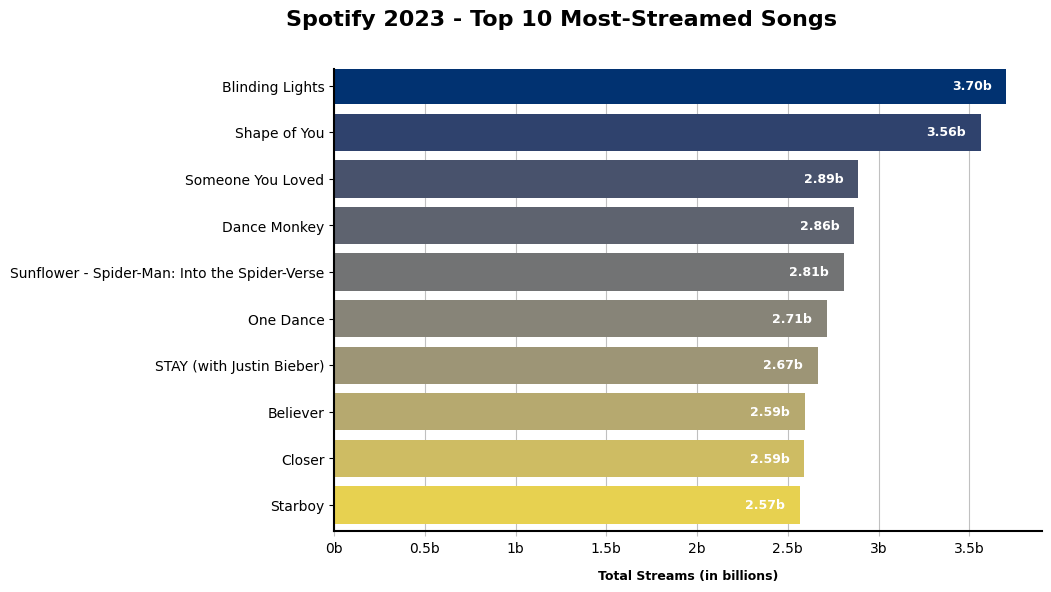

In [21]:
fig, ax = plt.subplots(figsize=(12,6))
fig.set_facecolor('white')
ax.set_facecolor('white')

paleta = sns.color_palette('cividis_r', n_colors=len(top10Songs))

chart = ax.barh(top10Songs, top10Streams, color=paleta)

fig.suptitle("Spotify 2023 - Top 10 Most-Streamed Songs", fontsize=16, weight='bold', y=0.98)

ax.set_xlabel("Total Streams (in billions)", fontsize=9, weight='bold', labelpad=10)
ax.xaxis.get_offset_text().set_visible(False)

ax.grid(True, axis='x', color='silver')
ax.set_axisbelow(True)

ax.set_xlim(0e9, 3.9e9)  
ticks = [0e9, 0.5e9, 1e9, 1.5e9, 2e9, 2.5e9, 3e9, 3.5e9]
labels = ['0b', '0.5b', '1b', '1.5b', '2b', '2.5b', '3b', '3.5b']
ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ymin, ymax = ax.get_ylim()
padmin = (ymax - ymin) * 0.03
padmax = (ymax - ymin) * 0.05
ax.set_ylim(ymin + padmin, ymax - padmax)

ax.tick_params(axis='x', color='silver')

sns.despine()
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

for bar in chart:
    width = bar.get_width()
    ax.text(
        width - 0.3e9,
        bar.get_y() + bar.get_height()/2, f"{width/1e9:.2f}b", ha="left", va="center", fontsize=9, color='white', weight='bold')
    
plt.subplots_adjust(left=0.31)
plt.savefig(output_dir / 'spotify.png', dpi=300)

plt.show()

### Horizontal Bar Chart - Top 5 Most-Streamed Artists on Spotify in 2023

In [22]:
top5Artist = df.groupby('artist(s)_name', as_index=False)['streams'].sum()
top5Artist = top5Artist.sort_values(by='streams', ascending=False).head(5)

topStreams = top5Artist['streams'].tolist()
topArtists = top5Artist['artist(s)_name'].tolist()

topStreams.reverse()
topArtists.reverse()

print(topStreams, topArtists)

[9997799607, 11608645649, 13908947204, 14053658300, 14185552870] ['Bad Bunny', 'Harry Styles', 'Ed Sheeran', 'Taylor Swift', 'The Weeknd']


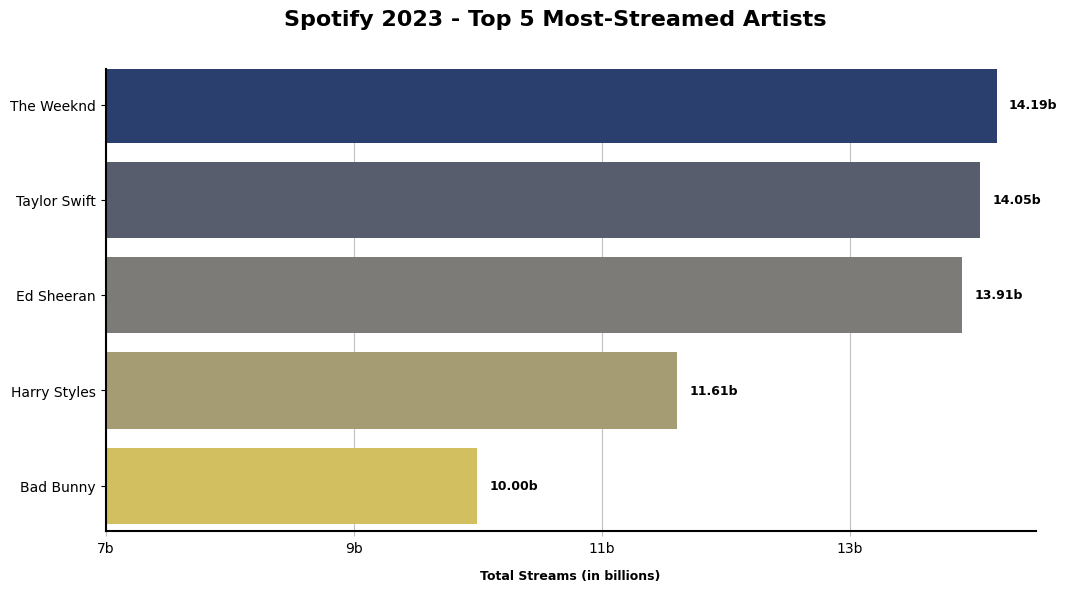

In [23]:
fig, ax = plt.subplots(figsize=(12,6))
fig.set_facecolor('white')
ax.set_facecolor('white')

paleta = sns.color_palette('cividis_r', n_colors=len(topStreams))

chart2 = ax.barh(topArtists, topStreams, color=paleta)

fig.suptitle("Spotify 2023 - Top 5 Most-Streamed Artists", fontsize=16, weight='bold', y= 0.98)
ax.set_xlabel("Total Streams (in billions)", fontsize=9, weight='bold', labelpad=10)
ax.xaxis.get_offset_text().set_visible(False)

ax.grid(True, axis='x', color='silver')
ax.set_axisbelow(True)

ax.set_xlim(7e9, 14.5e9)
ticks = [7e9, 9e9, 11e9, 13e9]
labels = ['7b', '9b', '11b', '13b']
ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ymin, ymax = ax.get_ylim()
padmin = (ymax - ymin) * 0.03
padmax = (ymax - ymin) * 0.05
ax.set_ylim(ymin + padmin, ymax - padmax)

ax.tick_params(axis='x', color='silver')

sns.despine()
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

for bar in chart2:
    width = bar.get_width()
    ax.text(
        width + 0.1e9,
        bar.get_y() + bar.get_height()/2, f"{width/1e9:.2f}b", ha="left", va="center", fontsize=9, weight='bold' )

plt.savefig(output_dir / 'spotify2.png',dpi=300)
plt.show()

### Pie Chart - New Songs vs Old Songs (Streams in 2023)

In [24]:
streamsYears = df.groupby('released_year', as_index=False)['streams'].sum()
streams2023 = streamsYears[streamsYears['released_year'] == 2023]
streamsGeneral = streamsYears[streamsYears['released_year'] != 2023]

totalGeneral = streamsGeneral['streams'].sum()
total2023 = streams2023['streams'].sum()

numbers = [totalGeneral, total2023]
labels = ['Other Years', '2023']

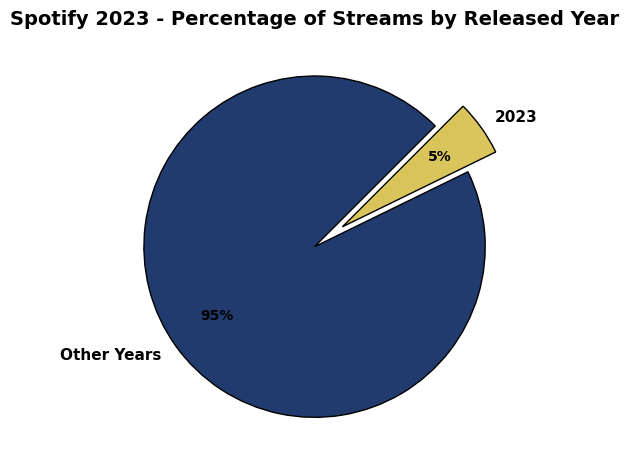

In [25]:
explode = [0, 0.2]
paleta = sns.color_palette('cividis')
color1 = paleta[0]
color2 = paleta[-1]

wedges, texts, autotexts = plt.pie(numbers, labels=labels, colors=[color1, color2], explode=explode, 
        wedgeprops={'edgecolor': 'black'}, startangle=45, autopct='%.0f%%', pctdistance=0.70)

for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

plt.title("Spotify 2023 - Percentage of Streams by Released Year", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / 'spotify3.png', dpi=300)
plt.show()

### Pie Chart - Streams by Song Mode

In [26]:
major = (df['mode'] == 'Major').sum()
minor = (df['mode'] == 'Minor').sum()

totalMode = [major, minor]
labels2 = ['Major Mode', 'Minor Mode']
explode2 = [0, 0.05]

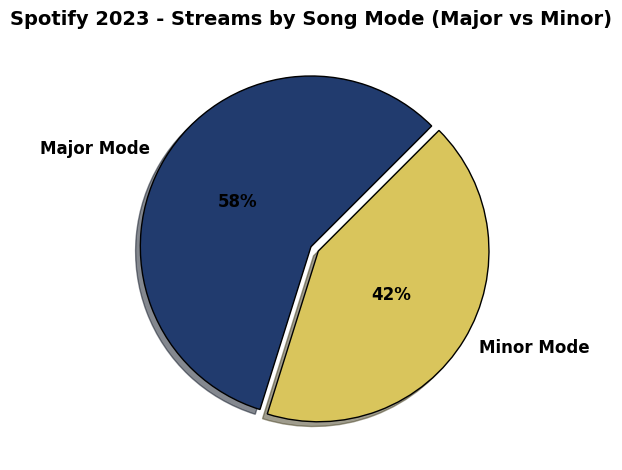

In [27]:
paleta = sns.color_palette('cividis')
color1 = paleta[0]
color2 = paleta[-1]

wedges, texts, autotexts = plt.pie(totalMode, labels=labels2, explode=explode2, wedgeprops={'edgecolor':'black'}, colors=[color1, color2],
       startangle=45, autopct='%.0f%%', pctdistance=0.50, shadow=True)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

plt.title("Spotify 2023 - Streams by Song Mode (Major vs Minor)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / 'spotify4.png', dpi=300)
plt.show()

### Bar Chart – Streams by Season of Release

In [28]:
streamsSeasons = df.groupby('season', as_index=False)['streams'].sum()
streamsSeasons = streamsSeasons.sort_values(by='streams', ascending=False)

season = streamsSeasons['season'].tolist()
streams = streamsSeasons['streams'].tolist()

C:\Users\joaov\AppData\Local\Temp\ipykernel_20972\4269087912.py:5: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  chart3 = sns.barplot(x=season, y=streams, hue=season, palette=paleta)


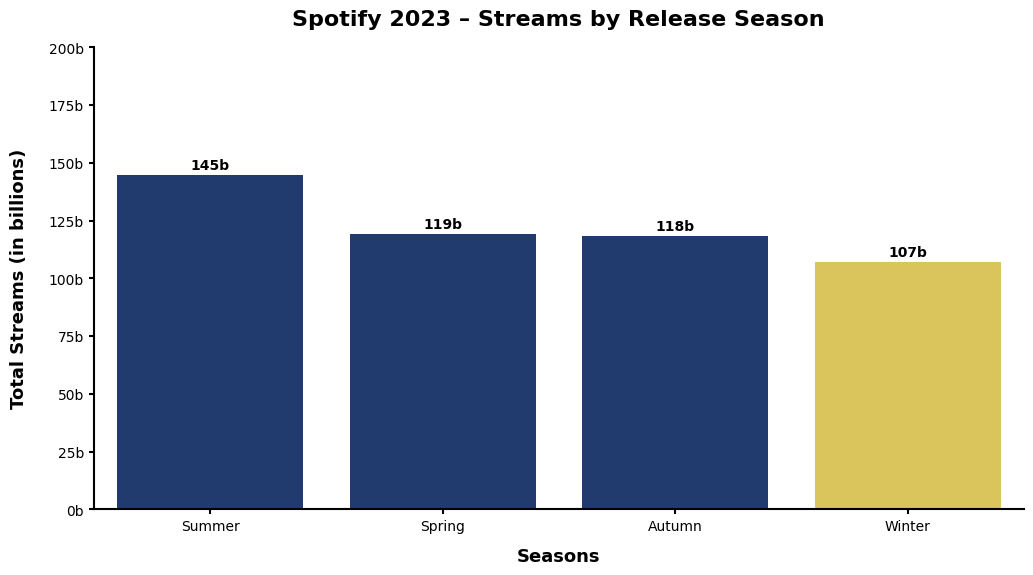

In [29]:
paleta = sns.color_palette('cividis')

fig, ax = plt.subplots(figsize=(12,6))

chart3 = sns.barplot(x=season, y=streams, hue=season, palette=paleta)

ax.set_xlabel("Seasons", fontsize=13, labelpad=10, fontweight='bold')
ax.set_ylabel("Total Streams (in billions)", fontsize=13, labelpad=15, fontweight='bold')
ax.set_title("Spotify 2023 – Streams by Release Season", fontsize=16, fontweight='bold', y=1.03)

ax.set_ylim(0e11, 2e11)
ticks = [0e11, 0.25e11, 0.50e11, 0.75e11, 1e11, 1.25e11, 1.5e11, 1.75e11, 2e11] 
labels = ['0b', '25b', '50b', '75b', '100b', '125b', '150b', '175b', '200b']
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

for container in chart3.containers:
    for valor in container.datavalues:
        ax.bar_label(container, labels=[f'{valor/1e9:.0f}b'], fontweight='bold', padding=2)

palette= [paleta[0], paleta[0],paleta[0],paleta[-1]]
color_dict = dict(zip(season, palette))

for i, patch in enumerate(chart3.patches):
    patch.set_facecolor(color_dict[season[i]])

sns.despine()
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5)

plt.savefig(output_dir / 'spotify5.png', dpi=300)
plt.show()

### Bar Chart – Classification of BPM Ranges

In [30]:
streamsBPM = df.groupby('classification', as_index=False)['streams'].sum().sort_values(by='streams', ascending=False)

classification = streamsBPM['classification'].tolist()
streamsClassification = streamsBPM['streams'].tolist()

print(classification)
print(streamsClassification)
display(streamsBPM)

['Medium', 'Medium-Fast', 'Fast', 'Very Fast', 'Medium-Slow', 'Slow']
[137585235996, 127849705808, 98093954471, 66239062947, 58004515115, 1686354205]


,classification,streams
1,Medium,137585235996
2,Medium-Fast,127849705808
0,Fast,98093954471
5,Very Fast,66239062947
3,Medium-Slow,58004515115
4,Slow,1686354205


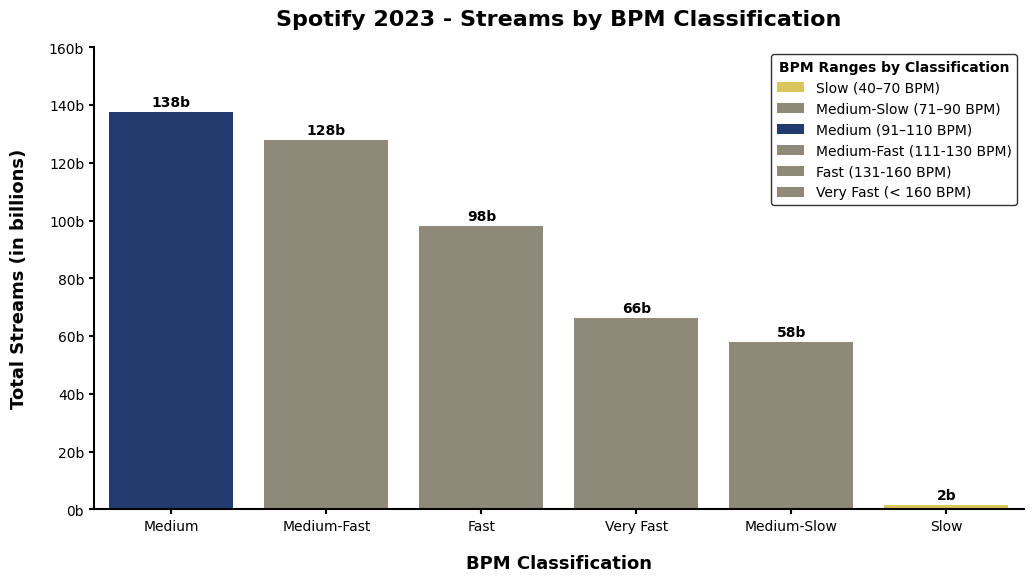

In [31]:
paleta = sns.color_palette('cividis')

fig, ax = plt.subplots(figsize=(12,6))

chart4 = sns.barplot(x=classification, y=streamsClassification, hue=classification, palette=paleta)

ax.set_xlabel('BPM Classification', fontweight='bold', fontsize=13, labelpad=15)
ax.set_ylabel('Total Streams (in billions)', fontweight='bold', fontsize=13, labelpad=15)
ax.set_title("Spotify 2023 - Streams by BPM Classification", fontsize=16, fontweight='bold', y=1.03)

ax.set_ylim(0e11, 1.6e11)
ticks = [0e11, 0.2e11, 0.4e11, 0.6e11, 0.8e11, 1e11, 1.2e11, 1.4e11, 1.6e11] 
labels = ['0b', '20b', '40b', '60b', '80b', '100b', '120b', '140b', '160b']
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

for container in chart4.containers: # access each bar
    for valor in container.datavalues: # access each bar value
        ax.bar_label(container, labels=[f'{valor/1e9:.0f}b'], fontweight='bold', padding=2) 
paleta = [paleta[0], paleta[3],paleta[3],paleta[3], paleta[3], paleta[-1]]
color_dict = dict(zip(classification, paleta))

for i, patch in enumerate(chart4.patches):
    patch.set_facecolor(color_dict[classification[i]])
#------------------------------------------------------------------------------
custom_names = {
    "Slow": "Slow (40–70 BPM)",
    "Medium-Slow": "Medium-Slow (71–90 BPM)",
    "Medium": "Medium (91–110 BPM)",
    "Medium-Fast": "Medium-Fast (111-130 BPM)",
    "Fast": "Fast (131-160 BPM)",
    "Very Fast": "Very Fast (< 160 BPM)"
}

patches = []
for c in custom_names:
    p = Patch(facecolor=color_dict[c], label=custom_names[c])
    patches.append(p)


legend = ax.legend(handles=patches, title="BPM Ranges by Classification", edgecolor='black')
legend.get_title().set_fontweight("bold")
#----------------------------------------------------------------------------------

sns.despine()
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5)

plt.savefig(output_dir / 'spotify6.png', dpi=300)
plt.show()

In [32]:
streamsBPM['range'] = streamsBPM['classification'].astype(str)

custom_names = {
    "Slow": "Slow (40–70 BPM)",
    "Medium-Slow": "Medium-Slow (71–90 BPM)",
    "Medium": "Medium (91–110 BPM)",
    "Medium-Fast": "Medium-Fast (111-130 BPM)",
    "Fast": "Fast (131-160 BPM)",
    "Very Fast": "Very Fast (< 160 BPM)"
}

streamsBPM['range'] = streamsBPM['range'].replace(custom_names)

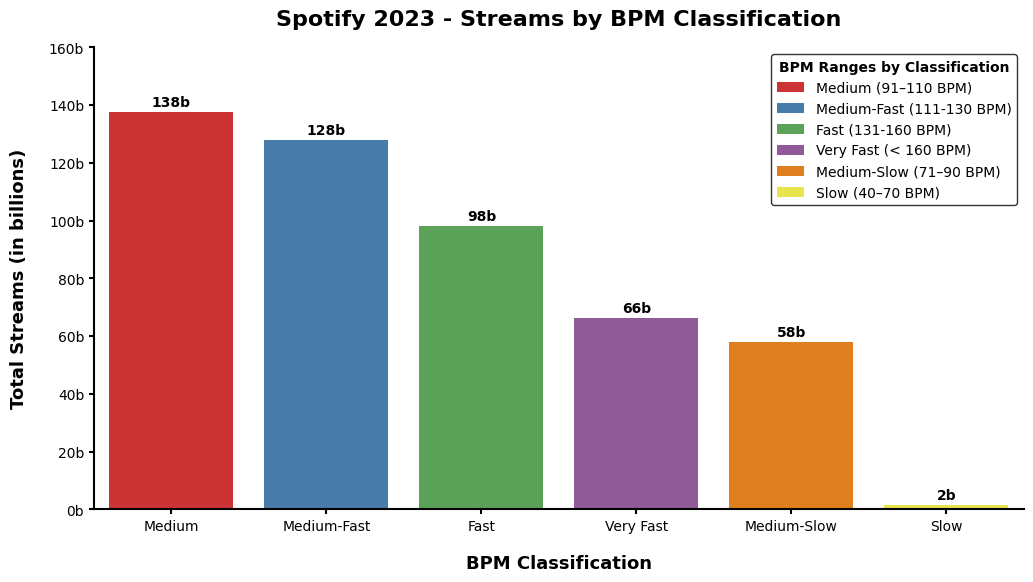

In [33]:
paleta = sns.color_palette('Set1', n_colors=6)

fig, ax = plt.subplots(figsize=(12,6))

chart4 = sns.barplot(data=streamsBPM, x='classification', y='streams', hue='range', palette=paleta)

ax.set_xlabel('BPM Classification', fontweight='bold', fontsize=13, labelpad=15)
ax.set_ylabel('Total Streams (in billions)', fontweight='bold', fontsize=13, labelpad=15)
ax.set_title("Spotify 2023 - Streams by BPM Classification", fontsize=16, fontweight='bold', y=1.03)

ax.set_ylim(0e11, 1.6e11)
ticks = [0e11, 0.2e11, 0.4e11, 0.6e11, 0.8e11, 1e11, 1.2e11, 1.4e11, 1.6e11] 
labels = ['0b', '20b', '40b', '60b', '80b', '100b', '120b', '140b', '160b']
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

for container in chart4.containers: # access each bar
    for valor in container.datavalues: # access each bar value 
        ax.bar_label(container, labels=[f'{valor/1e9:.0f}b'], fontweight='bold', padding=2) 

legend = ax.legend(title="BPM Ranges by Classification", edgecolor='black')
legend.get_title().set_fontweight("bold")


sns.despine()
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5)
plt.savefig(output_dir / 'spotify6_1.png', dpi=300)
plt.show()

### Histogram Chart – BPM Range Distribution

In [34]:
def calculate_bins(lista, step):
    minimo = min(lista)
    minimo = np.floor(minimo / step) * step

    maximo = max(lista)
    maximo = np.ceil(maximo / step) * step

    bins = np.arange(minimo, maximo + step, step).astype(int)
    return bins.tolist()

In [35]:
bins = calculate_bins(df['bpm'], 20)
print(f'Bins: {bins}')

bpm = df['bpm'].tolist() 

Bins: [60, 80, 100, 120, 140, 160, 180, 200, 220]


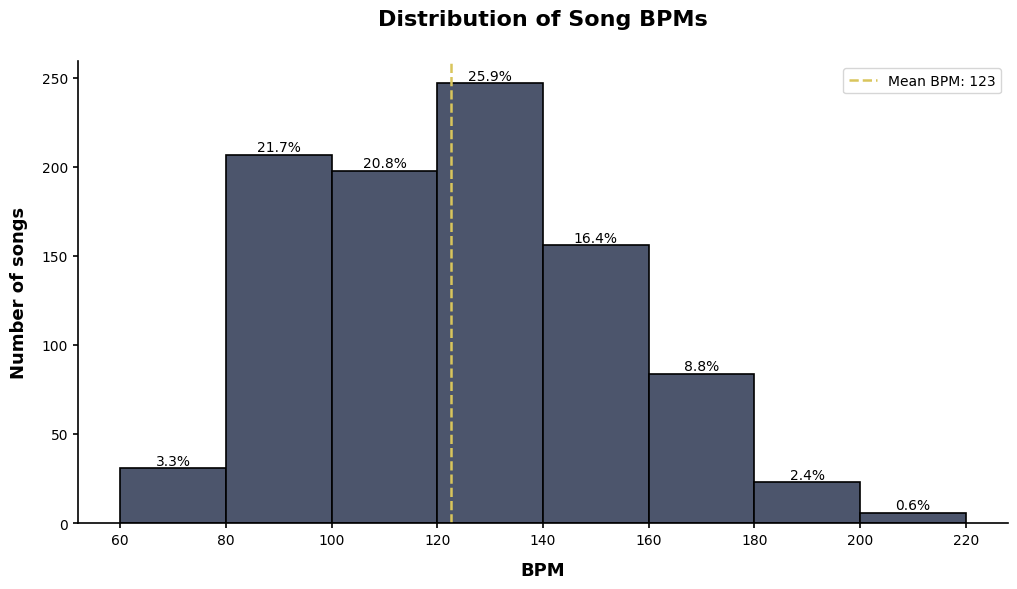

In [36]:
paleta = sns.color_palette('cividis')

fig, ax = plt.subplots(figsize=(12,6))

counts, bins_out, patches = ax.hist(bpm, bins=bins,color=paleta[1], edgecolor='black',linewidth=1.2)

total = sum(counts)
for i in range(len(counts)):
    percentual = (counts[i] / total) * 100
    ax.text(
        (bins_out[i] + bins_out[i+1]) / 2,  # bin center
        counts[i],                          # bar height
        f"{percentual:.1f}%",               # % value
        ha='center', va='bottom', fontsize=10, 
    )

mean_bpm = np.mean(bpm)
ax.axvline(mean_bpm, color=paleta[-1], linewidth=1.8, linestyle='--', label=f'Mean BPM: {mean_bpm:.0f}')
ax.legend()

ax.set_ylabel('Number of songs', fontsize=13, fontweight='bold', labelpad=10)
ax.set_xlabel('BPM', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title("Distribution of Song BPMs", fontsize=16, fontweight='bold', y=1.06)

sns.despine()
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='both', width=1.2)
plt.savefig(output_dir / 'spotify7.png', dpi=300)
plt.show()

### Bar Chart - Streams by Decade of Release

In [37]:
streamsDecades = df.groupby('decades', as_index=False)['streams'].sum().sort_values(by='streams', ascending=False)

centuries = {"2020's": "21st Century",
             "2010's": "21st Century",
             "2000's": "21st Century",
             "1990's": "20th Century",
             "1980's": "20th Century",
             "1970's": "20th Century",
             "1950's": "20th Century",
             "1960's": "20th Century",
             "1940's": "20th Century",
             "1930's": "20th Century"
}

streamsDecades['century'] = streamsDecades['decades'].astype(str).replace(centuries)

display(streamsDecades)

,decades,streams,century
9,2020's,250722696962,21st Century
8,2010's,178176477582,21st Century
7,2000's,23175971930,21st Century
6,1990's,13615632438,20th Century
5,1980's,10333155317,20th Century
4,1970's,6429158947,20th Century
2,1950's,3672782497,20th Century
3,1960's,2456990992,20th Century
1,1940's,785363360,20th Century
0,1930's,90598517,20th Century


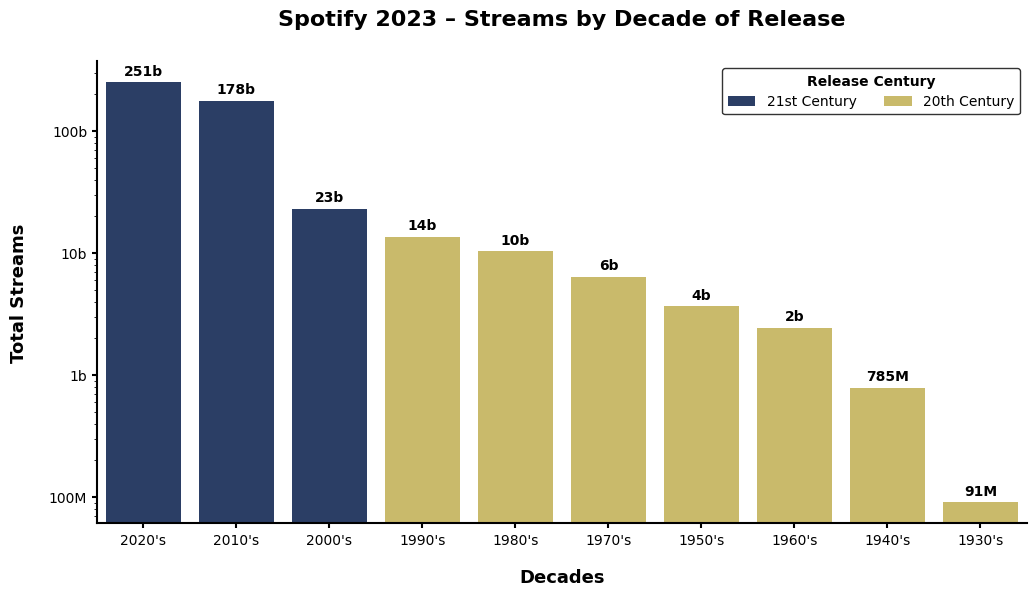

In [38]:
paleta = sns.color_palette('cividis')
colors = [paleta[0], paleta[-1]]

fig, ax = plt.subplots(figsize=(12,6))

chart6 = sns.barplot(data=streamsDecades, x='decades', y='streams', hue='century', palette=colors)

ax.set_xlabel('Decades', fontweight='bold', fontsize=13, labelpad=15)
ax.set_ylabel('Total Streams', fontweight='bold', fontsize=13, labelpad=15)
ax.set_title("Spotify 2023 – Streams by Decade of Release", fontsize=16, fontweight='bold', y=1.06)

plt.yscale("log")
legend = ax.legend(title= "Release Century", ncols=2, edgecolor='black')
legend.get_title().set_fontweight("bold")

ticks = [1e8, 1e9, 1e10, 1e11]
labels = ['100M', '1b', '10b', '100b']

ax.set_yticks(ticks)
ax.set_yticklabels(labels)    

#----------------------------------------------------------------------------------------
#for container in chart6.containers:
#    labels = []
#    for v in container.datavalues:
#        if v >= 1e9:
#            labels.append(f"{v/1e9:.0f}b")
#        else:
#            labels.append(f"{v/1e6:.0f}M")
 #   ax.bar_label(container, labels=labels, fontweight='bold', padding=3)

# List Comprehension
for container in chart6.containers:
    labels = [
        f"{v/1e9:.0f}b" if v >= 1e9 else f"{v/1e6:.0f}M"
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, fontweight='bold', padding=3)
#------------------------------------------------------------------------------------------

    
sns.despine()
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5)

plt.savefig(output_dir / 'spotify8.png', dpi=300)
plt.show()